In [28]:
import pandas as pd
df = pd.read_csv('../data/heart.csv')

In [29]:
%pip uninstall sklearn scikit-learn -y
%pip install scikit-learn mlxtend pandas


Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Note: you may need to restart the kernel to use updated packages.


## 1. Discretizați atributele numerice; lucrați cu mai multe metode

### Discretizare globală

In [30]:
from sklearn.preprocessing import KBinsDiscretizer

numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']
# strategies = ['uniform', 'quantile'] #  Cod sursă pt metode de discretizare - https://machinelearningmastery.com/discretization-transforms-for-machine-learning/
strategies = ['uniform', 'kmeans', 'quantile']

def apply_discretization(data, strategy, n_bins=3):
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
    data_disc = data.copy()
    
    # Aplicăm discretizarea pe coloanele numerice
    data_disc[numeric_cols] = discretizer.fit_transform(data[numeric_cols])
    
    # Mapăm numerele la etichete pentru lizibilitate (0=Low, 1=Med, 2=High)
    mapping = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
    for col in numeric_cols:
        data_disc[col] = data_disc[col].map(mapping)
        
    # Pregătim datele pentru Apriori (One-Hot Encoding)
    # Adăugăm numele coloanei la valoare pentru a identifica regula: "Age=Low"
    for col in data_disc.columns:
        data_disc[col] = col + "=" + data_disc[col].astype(str)
        
    return pd.get_dummies(data_disc)

### Discretizare granulată


In [55]:
# Configurație optimizată bazată pe distribuția datelor
feature_configs = {
    'Age': {'strategy': 'uniform', 'n_bins': 3},         # Distribuție uniformă, intervale de vârstă egale
    'RestingBP': {'strategy': 'uniform', 'n_bins': 3},   # Praguri clinice fixe (ex. tensiune mică/mare)
    'Cholesterol': {'strategy': 'quantile', 'n_bins': 4},# Are outliers; quantile asigură grupuri egale
    'MaxHR': {'strategy': 'kmeans', 'n_bins': 3},        # Grupare naturală a ritmului cardiac
    'Oldpeak': {'strategy': 'quantile', 'n_bins': 3}     # Distribuție asimetrică spre zero
}

def apply_custom_discretization(data, configs):
    data_disc = data.copy()
    mapping = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
    
    for col, settings in configs.items():
        discretizer = KBinsDiscretizer(
            n_bins=settings['n_bins'], 
            encode='ordinal', 
            strategy=settings['strategy']
        )
        
        data_disc[col] = discretizer.fit_transform(data[[col]])
        data_disc[col] = data_disc[col].map(mapping)
    for col in data_disc.columns:
        data_disc[col] = col + "=" + data_disc[col].astype(str)
        
    return pd.get_dummies(data_disc)

df_final = apply_custom_discretization(df, feature_configs)

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## 2. Fixați praguri pentru metricile suport și încredere

In [31]:

suport = [0.2, 0.3, 0.4]
conf = [0.7, 0.8, 0.9]

## 3. Extrageți regulile de asociere utilizând apriori (opțional și fp-growth); ordonați regulile după metricile discutate și identificați reguli ce pot căpăta o interpretare utilă

### Apriori


#### Discretizarea globală

In [49]:
from mlxtend.frequent_patterns import apriori, association_rules

results = {}
apriori_plot_data = []

for s in suport:
    for c in conf:
        print(f"Analiza regulilor de asociere (Suport={s}, Confidență={c}):\n")

        for strat in strategies:
            df_ready = apply_discretization(df, strategy=strat, n_bins=3)
            
            # Extragere seturi frecvente === apriori sau fpgrowth
            frequent_itemsets = apriori(df_ready, min_support=s, use_colnames=True)
            
            # Generare reguli
            rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
            results[strat] = rules
            count = len(rules)
            
            print(f"Strategia {strat.upper()}: {count} reguli găsite.")

            # 3. Identificarea regulilor utile
            best_rules = results[strat].sort_values(by='lift', ascending=False).head(5)
            print("\nTop 5 reguli utile (Strategia Quantile):")
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', None)
            for idx, row in best_rules.iterrows():
                print(f"Antecedents: {row['antecedents']} => Consequents: {row['consequents']}")
                print(f"  Support: {row['support']:.4f}\n  Confidence: {row['confidence']:.4f}\n  Lift: {row['lift']:.4f}\n")
            
            apriori_plot_data.append({
                'Suport': s,
                'Incredere': c,
                'Strategie': strat,
                'NrReguli': count
            })

            print("-" * 80)

Analiza regulilor de asociere (Suport=0.2, Confidență=0.7):

Strategia UNIFORM: 872 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2462
  Confidence: 0.7986
  Lift: 2.5193

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'})
  Support: 0.2462
  Confidence: 0.7766
  Lift: 2.5193

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2462
  Confidence: 0.8828
  Lift: 2.4048

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Sl

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia KMEANS: 315 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'})
  Support: 0.2549
  Confidence: 0.8041
  Lift: 2.3736

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2549
  Confidence: 0.8298
  Lift: 2.2604

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2810
  Confidence: 0.8296
  Lift: 2.2598

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'})
  Support: 0.2549

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia UNIFORM: 108 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3170
  Confidence: 0.7098
  Lift: 1.9334

Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3170
  Confidence: 0.8635
  Lift: 1.9334

Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3105
  Confidence: 0.8533
  Lift: 1.9105

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.3170
  Confidence: 0.8197
  Lift: 1.9051

Antecedents: frozenset({'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia QUANTILE: 54 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.3181
  Confidence: 0.8488
  Lift: 1.9727

Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3170
  Confidence: 0.8635
  Lift: 1.9334

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3181
  Confidence: 0.8588
  Lift: 1.9229

Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3105
  Confidence: 0.8533
  Lift: 1.9105

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia QUANTILE: 17 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'HeartDisease_HeartDisease=1'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Flat'})
  Support: 0.4150
  Confidence: 0.7500
  Lift: 1.4967

Antecedents: frozenset({'ST_Slope_ST_Slope=Flat'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.4150
  Confidence: 0.8283
  Lift: 1.4967

Antecedents: frozenset({'HeartDisease_HeartDisease=1'}) => Consequents: frozenset({'ChestPainType_ChestPainType=ASY'})
  Support: 0.4270
  Confidence: 0.7717
  Lift: 1.4282

Antecedents: frozenset({'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.4270
  Confidence: 0.7903
  Lift: 1.4282

Antecedents: frozenset({'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium'})
  Support: 0.4641
  Confidence: 0.7788
  Lift: 1.2348

-------------------------------------------------------------------------

#### Discretizare granulată

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

results = {}
apriori_custom_plot_data = []

for s in suport:
    for c in conf:
        print(f"Analiza regulilor de asociere (Suport={s}, Confidență={c}):\n")

        df_ready = apply_custom_discretization(df, feature_configs)
        
        # Extragere seturi frecvente === apriori sau fpgrowth
        frequent_itemsets = apriori(df_ready, min_support=s, use_colnames=True)
        
        # Generare reguli
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
        results[strat] = rules
        count = len(rules)
        
        print(f"Strategia {strat.upper()}: {count} reguli găsite.")

        # 3. Identificarea regulilor utile
        best_rules = results[strat].sort_values(by='lift', ascending=False).head(5)
        print("\nTop 5 reguli utile (Strategia Quantile):")
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        for idx, row in best_rules.iterrows():
            print(f"Antecedents: {row['antecedents']} => Consequents: {row['consequents']}")
            print(f"  Support: {row['support']:.4f}\n  Confidence: {row['confidence']:.4f}\n  Lift: {row['lift']:.4f}\n")
        
        apriori_custom_plot_data.append({
            'Suport': s,
            'Incredere': c,
            'Strategie': strat,
            'NrReguli': count
        })

        print("-" * 80)

Analiza regulilor de asociere (Suport=0.2, Confidență=0.7):

Strategia UNIFORM: 615 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.8500
  Lift: 2.2683

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.8438
  Lift: 2.2516

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2658
  Confidence: 0.8385
  Lift: 2.2376

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset(

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia UNIFORM: 336 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.8500
  Lift: 2.2683

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.8438
  Lift: 2.2516

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2658
  Confidence: 0.8385
  Lift: 2.2376

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'Exe

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia KMEANS: 88 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.9397
  Lift: 2.1040

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.2059
  Confidence: 0.9000
  Lift: 2.0916

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Medium', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.9265
  Lift: 2.0744

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Medium', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozens

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia UNIFORM: 59 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.3181
  Confidence: 0.8488
  Lift: 1.9727

Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3170
  Confidence: 0.8635
  Lift: 1.9334

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3181
  Confidence: 0.8588
  Lift: 1.9229

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
  Support: 0.3105
  Confidence: 0.8533
  Lift: 1.9105

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.3

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia QUANTILE: 8 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'ST_Slope_ST_Slope=Flat', 'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.3148
  Confidence: 0.9088
  Lift: 1.6423

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3170
  Confidence: 0.9180
  Lift: 1.5406

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3039
  Confidence: 0.9029
  Lift: 1.5153

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium'})
  Support: 0.3181
  Confidence: 0.9211
  Lift: 1.4605

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngi

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

### Fp-Growth

#### Discretizare globală

In [60]:
from mlxtend.frequent_patterns import association_rules, fpgrowth

results = {}
fp_plot_data = []

for s in suport:
    for c in conf:
        print(f"Analiza regulilor de asociere (Suport={s}, Confidență={c}):\n")

        for strat in strategies:
            df_ready = apply_discretization(df, strategy=strat, n_bins=3)
            
            # Extragere seturi frecvente === apriori sau fpgrowth
            frequent_itemsets = fpgrowth(df_ready, min_support=s, use_colnames=True)
            
            # Generare reguli
            rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
            results[strat] = rules
            count = len(rules)
            
            print(f"Strategia {strat.upper()}: {count} reguli găsite.")

            # 3. Identificarea regulilor utile
            best_rules = results[strat].sort_values(by='lift', ascending=False).head(5)
            print("\nTop 5 reguli utile (Strategia Quantile):")
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', None)
            for idx, row in best_rules.iterrows():
                print(f"Antecedents: {row['antecedents']} => Consequents: {row['consequents']}")
                print(f"  Support: {row['support']:.4f}\n  Confidence: {row['confidence']:.4f}\n  Lift: {row['lift']:.4f}\n")
            
            fp_plot_data.append({
                'Suport': s,
                'Incredere': c,
                'Strategie': strat,
                'NrReguli': count
            })

            print("-" * 80)

Analiza regulilor de asociere (Suport=0.2, Confidență=0.7):

Strategia UNIFORM: 872 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2462
  Confidence: 0.7986
  Lift: 2.5193

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'})
  Support: 0.2462
  Confidence: 0.7766
  Lift: 2.5193

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2462
  Confidence: 0.8828
  Lift: 2.4048

Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_O

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia QUANTILE: 520 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.8500
  Lift: 2.2683

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.8438
  Lift: 2.2516

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2658
  Confidence: 0.8385
  Lift: 2.2376

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseA

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia QUANTILE: 286 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.8500
  Lift: 2.2683

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.8438
  Lift: 2.2516

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2658
  Confidence: 0.8385
  Lift: 2.2376

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'Ex

...

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia KMEANS: 7 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'ST_Slope_ST_Slope=Flat'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.4150
  Confidence: 0.8283
  Lift: 1.4967

Antecedents: frozenset({'Oldpeak_Oldpeak=Low'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.4259
  Confidence: 0.8163
  Lift: 1.3699

Antecedents: frozenset({'HeartDisease_HeartDisease=1'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4989
  Confidence: 0.9016
  Lift: 1.1416

Antecedents: frozenset({'Cholesterol_Cholesterol=Medium'}) => Consequents: frozenset({'FastingBS_FastingBS=0'})
  Support: 0.4325
  Confidence: 0.8358
  Lift: 1.0899

Antecedents: frozenset({'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4641
  Confidence: 0.8589
  Lift: 1.0875

--------------------------------------------------------------------------------
Strategia QUANTILE: 5 reguli găsite.

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia KMEANS: 1 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'HeartDisease_HeartDisease=1'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4989
  Confidence: 0.9016
  Lift: 1.1416

--------------------------------------------------------------------------------
Strategia QUANTILE: 1 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'HeartDisease_HeartDisease=1'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4989
  Confidence: 0.9016
  Lift: 1.1416

--------------------------------------------------------------------------------


d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


#### Discretizare granulată

In [64]:
results = {}
custom_fp_plot_data = []

for s in suport:
    for c in conf:
        print(f"Analiza regulilor CUSTOM (Suport={s}, Confidență={c}):\n")

        # Aplici discretizarea personalizată O SINGURĂ DATĂ
        df_ready = apply_custom_discretization(df, feature_configs)
        
        # Extragere seturi frecvente
        frequent_itemsets = fpgrowth(df_ready, min_support=s, use_colnames=True)
        
        # Generare reguli
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
        count = len(rules)
        
        print(f"Strategia CUSTOM: {count} reguli găsite.")

        if count > 0:
            best_rules = rules.sort_values(by='lift', ascending=False).head(5)
            for idx, row in best_rules.iterrows():
                print(f"Antecedents: {row['antecedents']} => Consequents: {row['consequents']}")
                print(f"  Support: {row['support']:.4f}\n  Confidence: {row['confidence']:.4f}\n  Lift: {row['lift']:.4f}\n")
        
        custom_fp_plot_data.append({
            'Suport': s,
            'Incredere': c,
            'Strategie': 'Custom',
            'NrReguli': count
        })
        print("-" * 80)

Analiza regulilor CUSTOM (Suport=0.2, Confidență=0.7):



d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia CUSTOM: 615 reguli găsite.
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.8500
  Lift: 2.2683

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.8438
  Lift: 2.2516

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2658
  Confidence: 0.8385
  Lift: 2.2376

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2658


d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia CUSTOM: 336 reguli găsite.
Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2037
  Confidence: 0.8500
  Lift: 2.2683

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2059
  Confidence: 0.8438
  Lift: 2.2516

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'})
  Support: 0.2658
  Confidence: 0.8385
  Lift: 2.2376

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 

...

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Strategia CUSTOM: 8 reguli găsite.
Antecedents: frozenset({'ST_Slope_ST_Slope=Flat', 'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.3148
  Confidence: 0.9088
  Lift: 1.6423

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3170
  Confidence: 0.9180
  Lift: 1.5406

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3039
  Confidence: 0.9029
  Lift: 1.5153

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium'})
  Support: 0.3181
  Confidence: 0.9211
  Lift: 1.4605

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'FastingB

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia CUSTOM: 5 reguli găsite.
Antecedents: frozenset({'ST_Slope_ST_Slope=Flat'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.4150
  Confidence: 0.8283
  Lift: 1.4967

Antecedents: frozenset({'HeartDisease_HeartDisease=1'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4989
  Confidence: 0.9016
  Lift: 1.1416

Antecedents: frozenset({'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4641
  Confidence: 0.8589
  Lift: 1.0875

Antecedents: frozenset({'ST_Slope_ST_Slope=Flat'}) => Consequents: frozenset({'Sex_Sex=M'})
  Support: 0.4194
  Confidence: 0.8370
  Lift: 1.0598

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium'}) => Consequents: frozenset({'FastingBS_FastingBS=0'})
  Support: 0.5087
  Confidence: 0.8066
  Lift: 1.0517

--------------------------------------------------------------------------------
Analiza regulilor CUSTOM (Suport=0.4, Confidență=0.9):

Strategia CUSTOM: 1 reguli găsite.
Antecedents: f

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## 4. Analizați

### Realizați grafice care să ofere suport în analiza rezultatelor (1p)

ploturi speciale pt metrici de asociare
1. Scatter plots cu confidence vs suport.
2. catscatter (Lift-ul - puncte de dif dimensiuni)
3. Alluvial Plot

#### Fiecare strategie

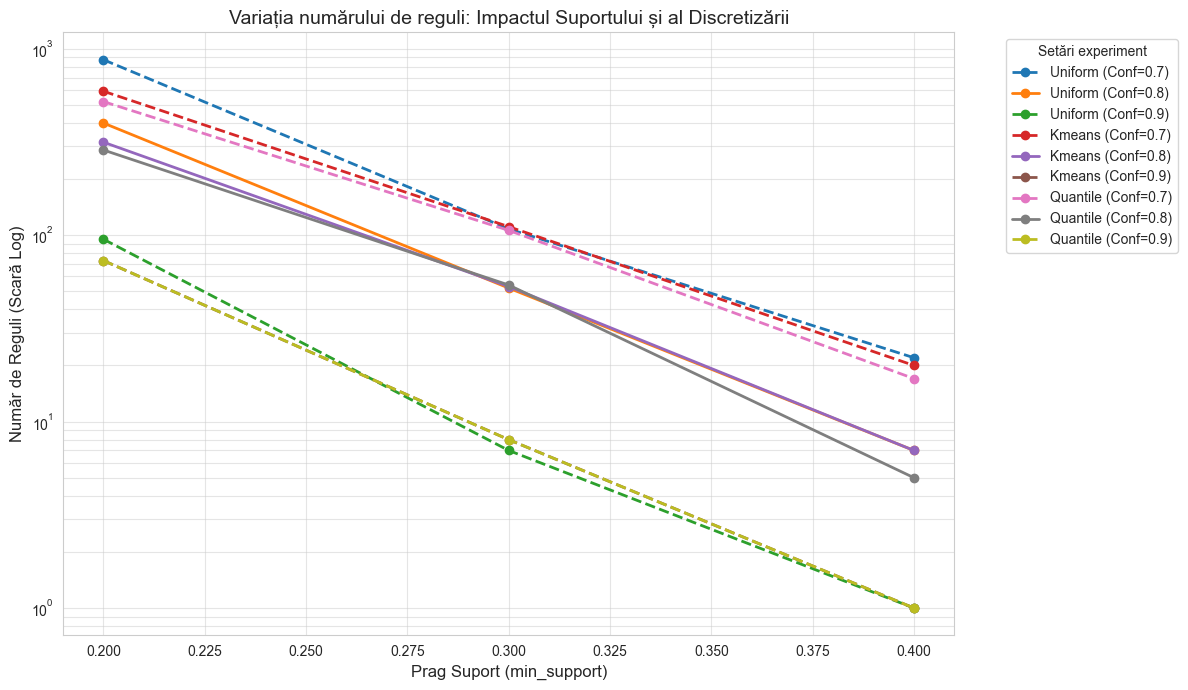

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_plot = pd.DataFrame(apriori_plot_data)
df_plot = pd.DataFrame(fp_plot_data)
# df_plot = pd.DataFrame(custom_fp_plot_data)


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

for strat in strategies:
    for c in conf:
        subset = df_plot[(df_plot['Strategie'] == strat) & (df_plot['Incredere'] == c)]
        line_style = '-' if c == 0.8 else '--'
        plt.plot(subset['Suport'], subset['NrReguli'], 
                 marker='o', linestyle=line_style, linewidth=2, 
                 label=f'{strat.capitalize()} (Conf={c})')

plt.yscale('log')
plt.title('Variația numărului de reguli: Impactul Suportului și al Discretizării', fontsize=14)
plt.xlabel('Prag Suport (min_support)', fontsize=12)
plt.ylabel('Număr de Reguli (Scară Log)', fontsize=12)
plt.legend(title="Setări experiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

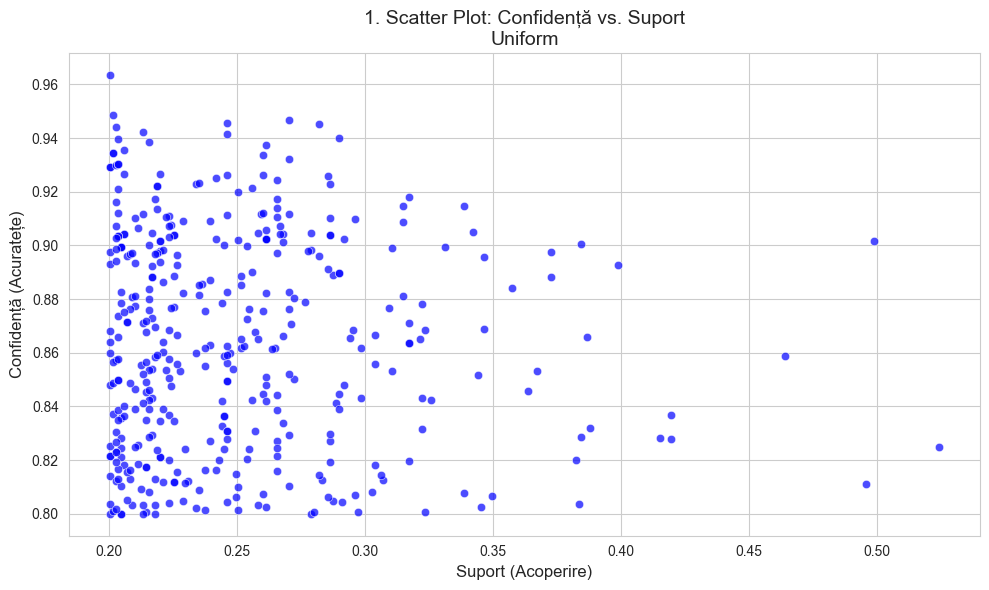

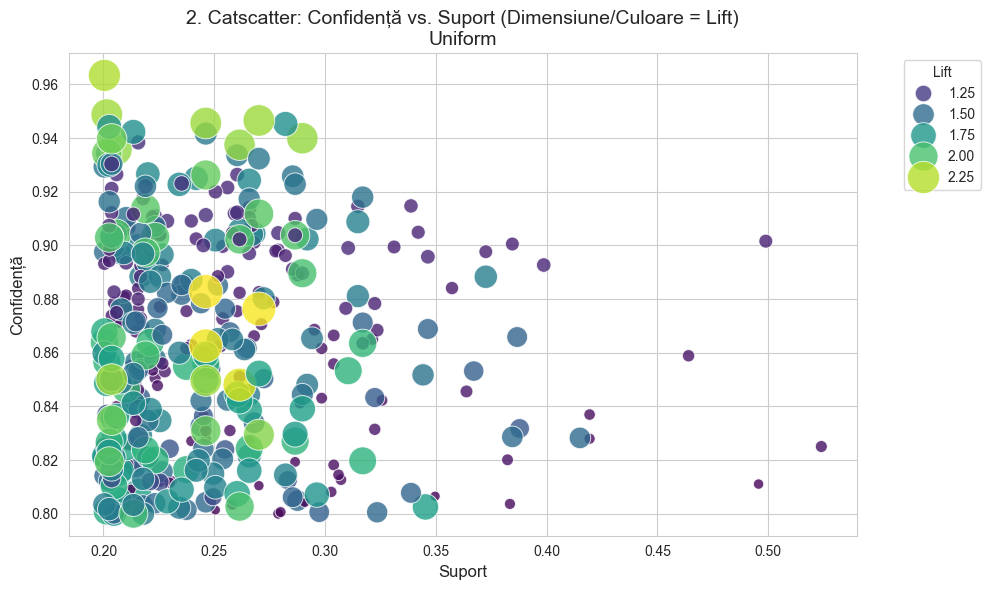

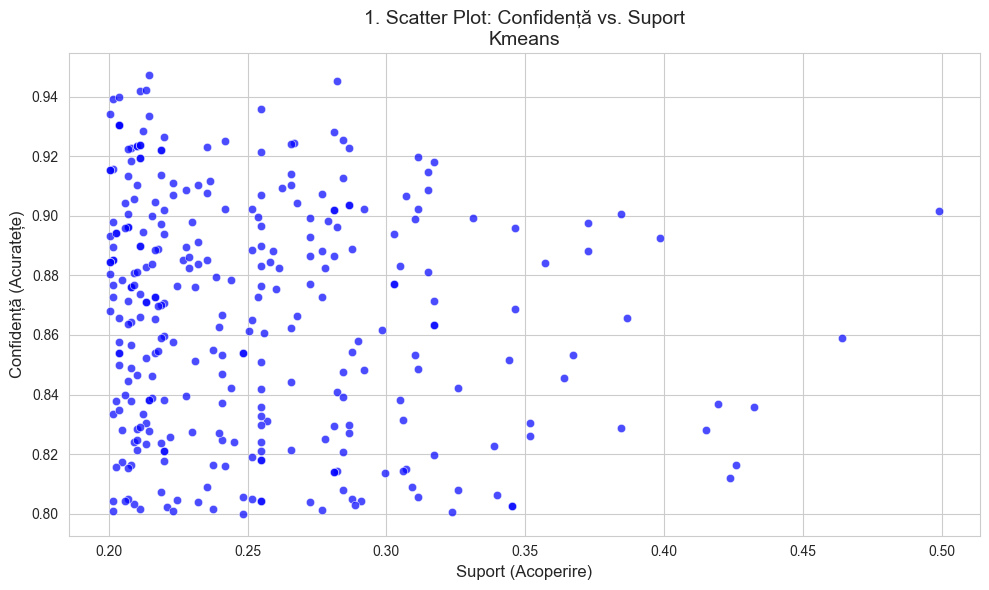

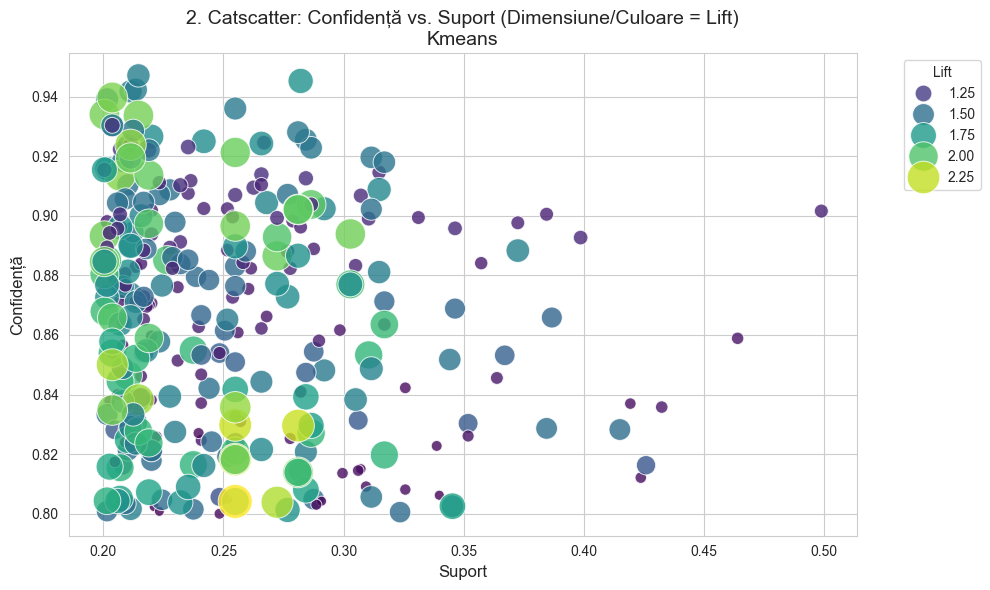

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


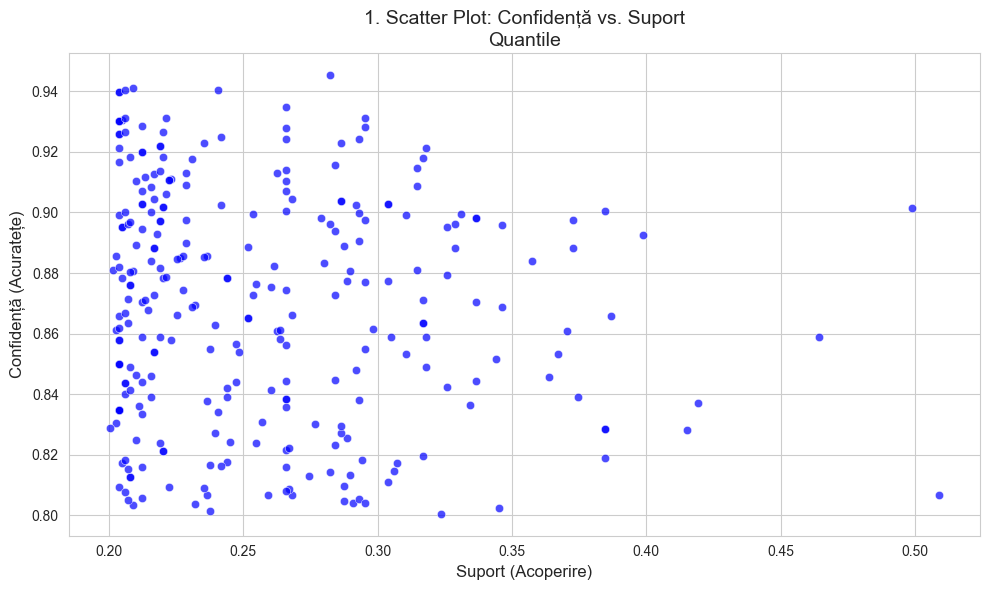

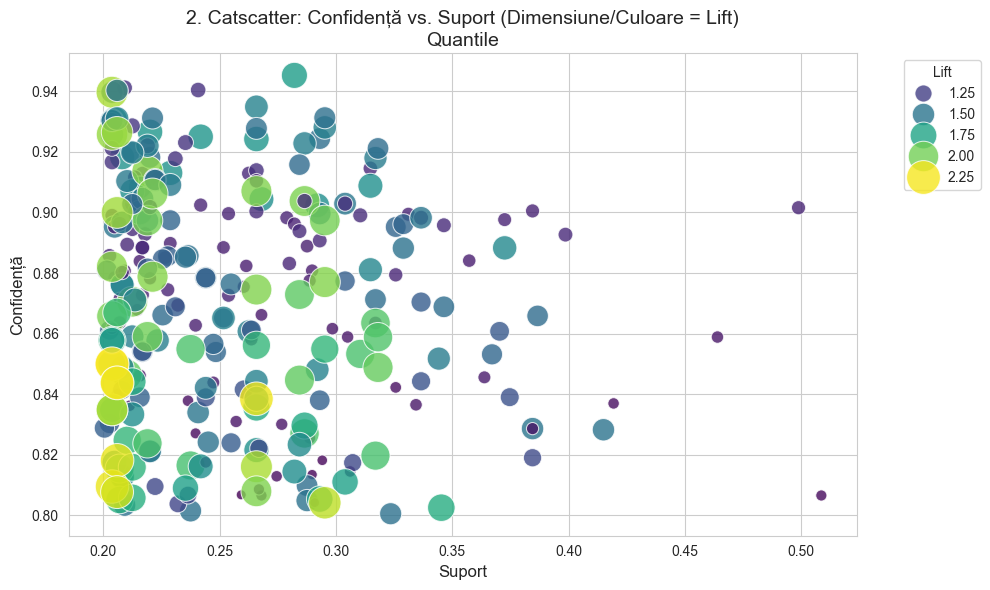

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, HTML

for strat in strategies:
    # df_final = apply_discretization(df, strategy=strat, n_bins=3)
    df_final = apply_discretization(df, strategy=strat, n_bins=3)

    freq = apriori(df_final, min_support=0.2, use_colnames=True)
    rules = association_rules(freq, metric="confidence", min_threshold=0.8)

    if not rules.empty:
        sns.set_style("whitegrid")
        
        # -------------------------------------------------------------------
        # 1. Scatter plot cu Confidence vs. Support
        # -------------------------------------------------------------------
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=rules, x='support', y='confidence', alpha=0.7, color='b')
        plt.title(f'1. Scatter Plot: Confidență vs. Suport\n{strat.capitalize()}', fontsize=14)
        plt.xlabel('Suport (Acoperire)', fontsize=12)
        plt.ylabel('Confidență (Acuratețe)', fontsize=12)
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------------------------
        # 2. Catscatter (Bubble plot): Dimensiunea punctelor indică Lift-ul
        # -------------------------------------------------------------------
        plt.figure(figsize=(10, 6))
        # Dimensiunea (size) și nuanța (hue) sunt dictate de metrica 'lift'
        scatter = sns.scatterplot(
            data=rules, 
            x='support', 
            y='confidence', 
            size='lift', 
            sizes=(50, 600), 
            hue='lift', 
            palette='viridis', 
            alpha=0.8
        )
        plt.title(f'2. Catscatter: Confidență vs. Suport (Dimensiune/Culoare = Lift)\n{strat.capitalize()}', fontsize=14)
        plt.xlabel('Suport', fontsize=12)
        plt.ylabel('Confidență', fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Lift")
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------------------------
        # 3. Alluvial Plot (Parallel Categories) folosind Plotly
        # -------------------------------------------------------------------
        # Pentru Plotly, trebuie să transformăm frozenset-urile în string-uri lizibile
        rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

        # Pentru a nu obține un grafic ilizibil (supraîncărcat), selectăm top 20 reguli după Lift
        top_rules = rules.sort_values('lift', ascending=False).head(20)

        fig = px.parallel_categories(
            top_rules,
            dimensions=['antecedents_str', 'consequents_str'],
            color='lift',
            color_continuous_scale=px.colors.sequential.Inferno,
            labels={'antecedents_str': 'Antecedenți', 'consequents_str': 'Consecvenți'}
        )
        fig.update_layout(
            title=f"3. Alluvial Plot: Fluxul de la Antecedenți la Consecvenți (Top 20 Reguli)\n{strat.capitalize()}",
            font=dict(size=11),
            margin=dict(t=80, b=80, l=80, r=100)
        )
        fig_html = fig.to_html(full_html=False, include_plotlyjs='cdn')
        display(HTML(fig_html))
    else:
        print("Nu există suficiente reguli generate pentru a trasa graficele. Reduceți pragurile de suport/confidență.")

#### Custom strategy

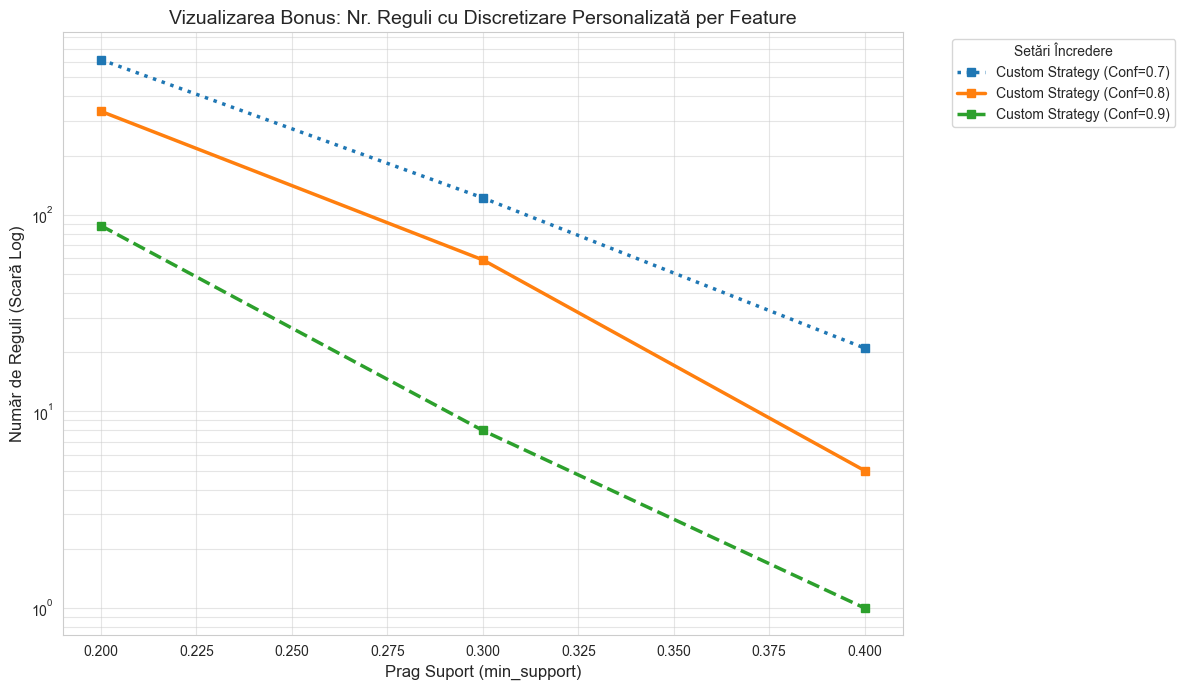

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Utilizăm datele din experimentul cu discretizare personalizată (Bonus)
df_plot_custom = pd.DataFrame(custom_fp_plot_data)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Filtrăm pentru a obține valorile unice de încredere din datele custom
conf_values = df_plot_custom['Incredere'].unique()

for c in conf_values:
    # Selectăm doar subsetul corespunzător încrederii c
    subset = df_plot_custom[df_plot_custom['Incredere'] == c]
    
    # Sortăm după suport pentru a asigura trasarea corectă a liniei
    subset = subset.sort_values('Suport')
    
    # Stilul liniei în funcție de pragul de încredere
    if c == 0.7: line_style = ':'
    elif c == 0.8: line_style = '-'
    else: line_style = '--'
    
    plt.plot(subset['Suport'], subset['NrReguli'], 
             marker='s', linestyle=line_style, linewidth=2.5, 
             label=f'Custom Strategy (Conf={c})')

# Setări axă și titluri
plt.yscale('log') # Scară logaritmică pentru a observa diferențele mari de magnitudine
plt.title('Vizualizarea Bonus: Nr. Reguli cu Discretizare Personalizată per Feature', fontsize=14)
plt.xlabel('Prag Suport (min_support)', fontsize=12)
plt.ylabel('Număr de Reguli (Scară Log)', fontsize=12)

plt.legend(title="Setări Încredere", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


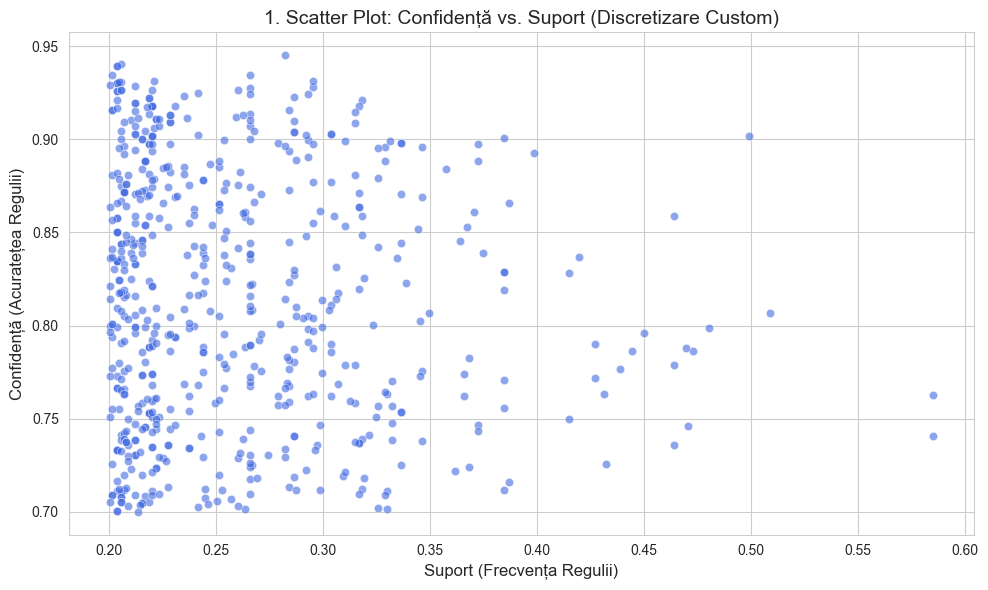

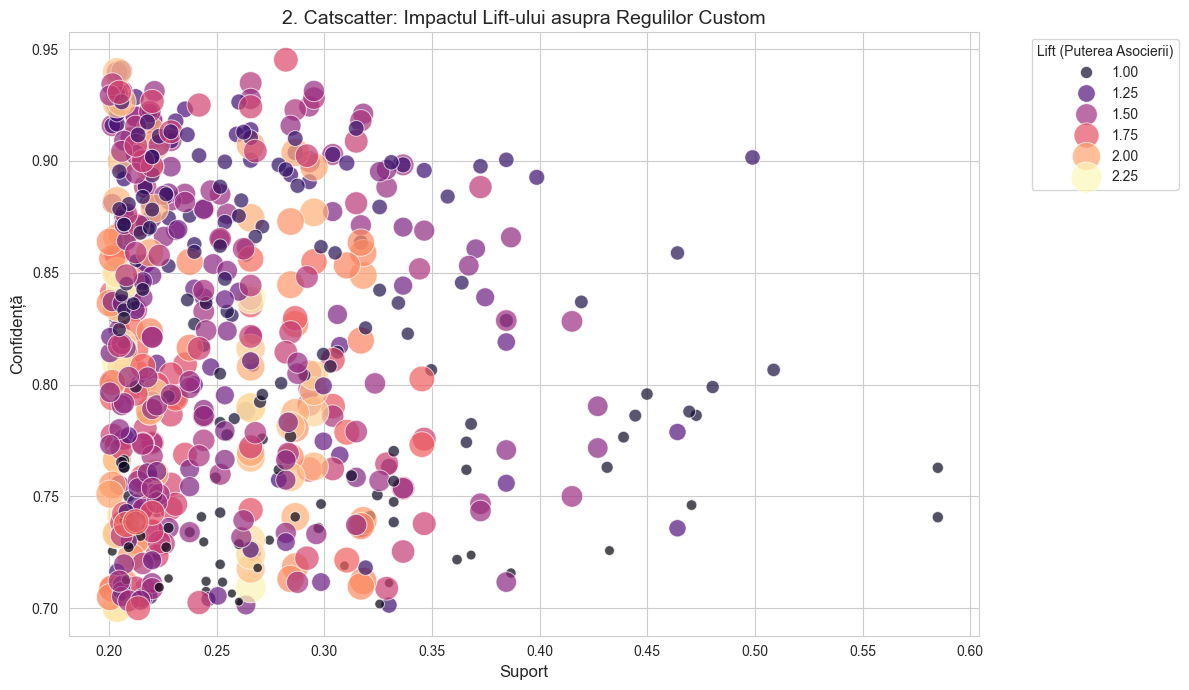

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
from IPython.display import display, HTML
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Utilizăm configurația optimizată per feature (Bonus)
# Aceasta include strategii specifice: Age (uniform), Cholesterol (quantile), MaxHR (kmeans) etc.
df_ready_custom = apply_custom_discretization(df, feature_configs)

# Extragem regulile de asociere folosind FP-Growth pentru eficiență
# Praguri setate: Suport minim 0.2 și Confidență minimă 0.7
frequent_itemsets = fpgrowth(df_ready_custom, min_support=0.2, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

if not rules.empty:
    sns.set_style("whitegrid")
    
    # -------------------------------------------------------------------
    # 1. Scatter plot cu Confidence vs. Support
    # -------------------------------------------------------------------
    # Acest grafic arată distribuția generală a regulilor pe baza acurateței (Confidență) 
    # și a frecvenței lor în date (Suport).
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rules, x='support', y='confidence', alpha=0.6, color='royalblue')
    plt.title('1. Scatter Plot: Confidență vs. Suport (Discretizare Custom)', fontsize=14)
    plt.xlabel('Suport (Frecvența Regulii)', fontsize=12)
    plt.ylabel('Confidență (Acuratețea Regulii)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------
    # 2. Catscatter (Bubble plot): Dimensiunea punctelor indică Lift-ul
    # -------------------------------------------------------------------
    # Lift-ul indică puterea asocierii. Dimensiunea mai mare a bulelor evidențiază 
    # regulile cele mai semnificative[cite: 1].
    plt.figure(figsize=(12, 7))
    scatter = sns.scatterplot(
        data=rules, 
        x='support', 
        y='confidence', 
        size='lift', 
        sizes=(40, 500), 
        hue='lift', 
        palette='magma', 
        alpha=0.7
    )
    plt.title('2. Catscatter: Impactul Lift-ului asupra Regulilor Custom', fontsize=14)
    plt.xlabel('Suport', fontsize=12)
    plt.ylabel('Confidență', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Lift (Puterea Asocierii)")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------
    # 3. Alluvial Plot (Parallel Categories) pentru Top 20 Reguli
    # -------------------------------------------------------------------
    # Vizualizează fluxul de la setul de antecedenți la consecvenți.
    # Convertim seturile în șiruri de caractere pentru compatibilitate cu Plotly[cite: 1].
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    # Selectăm top 20 reguli după Lift pentru a păstra graficul lizibil[cite: 1]
    top_rules = rules.sort_values('lift', ascending=False).head(20)

    fig = px.parallel_categories(
        top_rules,
        dimensions=['antecedents_str', 'consequents_str'],
        color='lift',
        color_continuous_scale=px.colors.sequential.Viridis,
        labels={'antecedents_str': 'Antecedenți', 'consequents_str': 'Consecvenți'}
    )
    fig.update_layout(
        title="3. Alluvial Plot: Fluxul Antecedenți -> Consecvenți (Top 20 Reguli după Lift)",
        font=dict(size=10),
        margin=dict(t=80, b=40, l=150, r=150)
    )
    
    # Afișarea graficului interactiv în Jupyter
    fig_html = fig.to_html(full_html=False, include_plotlyjs='cdn')
    display(HTML(fig_html))

else:
    print("Nu s-au generat reguli. Încercați să scădeți pragul de suport sau confidență.")

### Cum variază mulțimea de reguli la schimbarea pragurilor de la punctul 2? (2p)

Impactul pragului de suport:

    Se modifică drastic cardinalul mulțimilor de reguli de la un prag fixat de suport la altul. Pentru pragul 0.2 observăm un număr de +100 de mulțimi, timp în care pentru pragul 0.4 numărul asociat mulimilor de reguli este în intervalul [0,100]. În concluzie, mulțimile de reguli mai generale (potențial zgomot) au prag de suport > 30%, timp în care cele mai precise (poate prea precise/se poate pierde infomrație utiilă) au prag de suport < 30%.

Impactul pragului de încredere:

    Pragul de încredere shift-ează masiv numărul de reguli funcționând ca un filtru de calitate. Astfel cu cât pragul de încredere crește, cu atât vom depista un cardinal a mulțimilor de reguli mai scăzut. Pragul de 0.7 introduce mult zgomot, timp în care pragul de 0.9 reține doar certitudinile clinice/relevante.

### Care metodă de discretizare a datelor este de preferat pentru setul supus analizei? (2p)

Transformată de discretizare uniformă

    O transformare de discretizare uniformă va păstra distribuția de probabilitate a fiecărei variabile de intrare, dar o va face discretă cu numărul specificat de grupuri ordinale sau etichete (N). Astfel se vor realiza N secvențe egale pe baza cărora să se realizeze cele N grupuri cu elementele ce fac parte din secvența curentă. Putem aplica transformarea de discretizare uniformă folosind clasa KBinsDiscretizer și setând argumentul „strategy” la „uniform”. (Citat din https://machinelearningmastery.com/discretization-transforms-for-machine-learning/)

Transformată de discretizare cuantilă

    O transformare de discretizare cuantilă va încerca să împartă observațiile pentru fiecare variabilă de intrare în N grupuri, unde numărul de observații atribuite fiecărui grup este aproximativ egal. Cu excepția cazului în care există un număr mare de observații sau o distribuție empirică complexă, numărul de intervale trebuie menținut mic, cum ar fi 5-10. (Citat din https://machinelearningmastery.com/discretization-transforms-for-machine-learning/)

Transformată de discretizare KMeans

    Această transformare realizează gruparea valorilor folosind logica algritmului de clusterizare KMEans. Astfel se realizează cele N grupuri valorificând astfel limitele naturale ale setului de date.

Răspuns

    Metoda de dicretizare uniformă lasă un surplus de date fragmentate sever din cauza metodet care nu ține cont de nicio distribuție a datelor. Timp în care transformare de discretizare cuantilă oferă un echilibru între distribuțiile datelor ceea ce previne situația în care pragurile de suport elimină realizează grupări nule (cum ar fi cei cu colesterol extrem de mare) doar pentru că sunt puțini la număr sau sunt distribuiți neuniform. Metoda kmeans este o metodă intermediară a celor două. De asemenea se mai poate observa la nivelul statisticilor ce evidențiează volumul de reguli per metodă în funcție de cei doi parametrii (încredere și suport) că putem face o concluzie similară valorificând strict acele metode cu aceleași valori de încredere și suport. Astfel că pentru încrederea 0.7 și suportul 0.2 se vor observa diferențe drastice ale numărului de reguli găsite de la metoda Uniformă la cuantilă. Metoda Uniformă stabilește un număr apropriat de 1000 de reguli, timp în care metoda cuantilă atinge un număr de aproximativ 600. O diferență drastică ce justifică fragmentarea exagerată a metodei Uniforme care partiționează foarte aspru pacienții. Aceleași aspecte le vom observa și la nivelul celorlalte perechi de valori încredere-suport, astfel că metoda cuantilă devine metoda cea optimă. De asemenea metoda cuantilă realizează și găsește reguli cu lift-uri mari, încă un fapt evidențiat la nivelul plot-urilor catscatter.

Rezumat - de ce metoda cuantilă este cea mai potrivită metodă de discretizare?

    1. Compararea metodelor la nivelul fiecărei perechi încredere-suport - metoda cuantilă găssește reguli mai coompacte și ușor de interpretat, fără pierdferi de informație.
    2. Mai multe lift-uri mai mari față de restul metodelor.

DAR

    Și metoda/strategia custom vine cu câteva avantaje - găsește un număr de reguli mai optim ca taote, dar din păcate lift-ul este ușor mai mic per ansamblu.

    'Age': {'strategy': 'uniform', 'n_bins': 3},         # Distribuție uniformă, intervale de vârstă egale
    'RestingBP': {'strategy': 'uniform', 'n_bins': 3},   # Praguri clinice fixe (ex. tensiune mică/mare)
    'Cholesterol': {'strategy': 'quantile', 'n_bins': 4},# Are outliers; quantile asigură grupuri egale
    'MaxHR': {'strategy': 'kmeans', 'n_bins': 3},        # Grupare naturală a ritmului cardiac
    'Oldpeak': {'strategy': 'quantile', 'n_bins': 3}     # Distribuție asimetrică spre zero


### Extrageți reguli utile și motivați (2p)

#### Apriori

Regula 1:

    === Strategia QUANTILE: 73 reguli găsite (Suport=0.2, Confidență=0.9) ===
    Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0' 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
    - Support: 0.2037
    - Confidence: 0.9397
    - Lift: 2.1040

Oferă date pentru un pacient sănătos cu o probabilitate de aproximativ 94%. Această regilă este extrem utilă pentru eficientizarea selectării pacienților și resurselor (fără teste suplimentare inutile).


Regula 2:

    === Strategia UNIFORM: 9 reguli găsite (Suport=0.3, Confidență=0.9) ===
    Antecedents: frozenset({'ST_Slope_ST_Slope=Flat', 'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
    - Support: 0.3148
    - Confidence: 0.9088
    - Lift: 1.6423

Datele acestea ilustrează pacientul diagnosticat, dar care nu prezintă simptome evidente (dureroase) - ChestPainType=ASY! Extrem de utilă pentru a evita netratarea bolii la timp, din cauza lipselor semnelor de întrebare.

#### Fp-Geowth

Regula 1:

    ===Strategia QUANTILE: 8 reguli găsite. (Suport=0.3, Confidență=0.8) ===
    Antecedents: frozenset({'ST_Slope_ST_Slope=Flat', 'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
      Support: 0.3148
      Confidence: 0.9088
      Lift: 1.6423

  Regulă utilă pentru diagnosticarea sistemului cardiac. Astfel pacientul ce prezintă tipul de durere ASY (asimptotic) și st_slpe plat va fi diagnosticat cu heart_disease în proporție de aprox. 90%

Regula 2:
    
    === Strategia QUANTILE: 73 reguli găsite. (Suport=0.2, Confidență=0.7) ===
    Top 5 reguli utile (Strategia Quantile):
    Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
      Support: 0.2037
      Confidence: 0.9397
      Lift: 2.1040

  Regulă ce indică că pacienții un un semna EKG normal, st_slope ridicat și glicemia în limite nomrale nu va fi diagnosticat cu heart_disease în proporție de mai bine de 90%.

### Ce reguli pot fi extrase pentru a construi un clasificator? Comentați asupra calității acestora din punct de vedere al acurateței (confidență) și acoperirii (suport)(3p)

Comentariu pe baza Acc și Suport.